In [185]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.stats import zscore 
import re
import os

In [186]:
df = pd.read_csv("Location_dataset.csv")

## Dataset Overview

In [187]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [188]:
df.shape

(51717, 17)

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [190]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [191]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [192]:
df.describe(include = "object").T

,count,unique,top,freq
url,51717,51717,https://www.zomato.com/bangalore/the-nest-the-...,1
address,51717,11495,Delivery Only,128
name,51717,8792,Cafe Coffee Day,96
online_order,51717,2,Yes,30444
book_table,51717,2,No,45268
rate,43942,64,NEW,2208
phone,50509,14926,080 43334321,216
location,51696,93,BTM,5124
rest_type,51490,93,Quick Bites,19132
dish_liked,23639,5271,Biryani,182


In [193]:
(df.isnull().sum()/len(df))*100

url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

In [194]:
df.duplicated().sum()

np.int64(0)

In [195]:
df[df.duplicated(subset=['name', 'location'])].shape 

(39566, 17)

In [196]:
df.nunique()

url                            51717
address                        11495
name                            8792
online_order                       2
book_table                         2
rate                              64
votes                           2328
phone                          14926
location                          93
rest_type                         93
dish_liked                      5271
cuisines                        2723
approx_cost(for two people)       70
reviews_list                   22513
menu_item                       9098
listed_in(type)                    7
listed_in(city)                   30
dtype: int64

## Cleaning

In [197]:
df.rename(columns={'approx_cost(for two people)': 'cost_for_two', 'listed_in(type)': 'listed_type' , 'listed_in(city)': 'listed_city'}, inplace=True)
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'cost_for_two', 'reviews_list', 'menu_item', 'listed_type',
       'listed_city'],
      dtype='object')

In [198]:
corrupt_df = df[df['name'].str.contains('Ã|�||©', na=False)]
print(corrupt_df.shape)

(269, 17)


In [199]:
corrupt_df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,listed_type,listed_city
10,https://www.zomato.com/bangalore/caf%C3%A9-dow...,"12,29 Near PES University Back Gate, D'Souza N...",CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...,Yes,No,4.1/5,402,080 26724489\r\n+91 7406048982,Banashankari,Cafe,"Waffles, Pasta, Crispy Chicken, Honey Chilli C...",Cafe,500,"[('Rated 4.0', 'RATED\n We ended up here on a...",[],Cafes,Banashankari
193,https://www.zomato.com/bangalore/caf%C3%A9-dow...,"12,29 Near PES University Back Gate, D'Souza N...",CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...,Yes,No,4.1/5,402,080 26724489\r\n+91 7406048982,Banashankari,Cafe,"Waffles, Pasta, Crispy Chicken, Honey Chilli C...",Cafe,500,"[('Rated 4.0', 'RATED\n We ended up here on a...",[],Delivery,Banashankari
566,https://www.zomato.com/bangalore/caf%C3%A9-dow...,"12,29 Near PES University Back Gate, D'Souza N...",CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...,Yes,No,4.1/5,402,080 26724489\r\r\r\r\n+91 7406048982,Banashankari,Cafe,"Waffles, Pasta, Crispy Chicken, Honey Chilli C...",Cafe,500,"[('Rated 4.0', 'RATED\n We ended up here on a...","['Nutella Crepe', 'Waffles with Nutella', 'Veg...",Dine-out,Banashankari
974,https://www.zomato.com/bangalore/bohra-bohra-c...,"Shop 1, 129, 24th Main, 5th Phase, JP Nagar, B...",Bohra Bohra CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ©,Yes,No,3.6/5,43,+91 9880101051\r\r\n+91 9742661909,JP Nagar,Quick Bites,"Fruit Custard, Russian Cutlet",Bohri,300,"[('Rated 4.0', 'RATED\n If your craving to tr...","['Caramel Custard', 'Smoked Chicken Kheema Sam...",Delivery,Bannerghatta Road
1303,https://www.zomato.com/bangalore/foreign-caf%C...,"45, 14th Main, 7th Phase, Puttehahalli Palya, ...",Foreign CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ©,Yes,No,NaN,0,+91 8375867011\r\n+91 8217793626,JP Nagar,Delivery,NaN,Continental,500,[],[],Delivery,Bannerghatta Road


In [200]:
def clean_name(name):
    if pd.isna(name):
        return name
    cleaned = re.sub(r'[^A-Za-z0-9\s]', '', name)
    return cleaned.strip()
df['name'] = df['name'].apply(clean_name)

In [201]:
df['rate'].unique() 

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [202]:
df['rate'] = df['rate'].astype(str).str.extract(r'(\d+(?:\.\d+)?)', expand=False).astype(float)
df['rate'].dtypes

dtype('float64')

In [203]:
df['rate'].unique() 

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

In [204]:
df.describe()

,rate,votes
count,41665.000000,51717.000000
mean,3.700449,283.697527
std,0.440513,803.838853
min,1.800000,0.000000
25%,3.400000,7.000000
50%,3.700000,41.000000
75%,4.000000,198.000000
max,4.900000,16832.000000


In [205]:
df['cost_for_two'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', nan, '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

In [206]:
df['cost_for_two'] = df['cost_for_two'].astype(str).apply(lambda x: x.replace(',','') if isinstance(x,str) else x)
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors = 'coerce')
df['cost_for_two'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700.,   nan, 1400.,  180., 1350.,
       2200., 2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800.,
       3400.,   40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,
        469.,   70., 3200.,   60.,  560.,  240.,  360., 6000., 1050.,
       2300., 4100., 5000., 3700., 1650., 2700., 4500.,  140.])

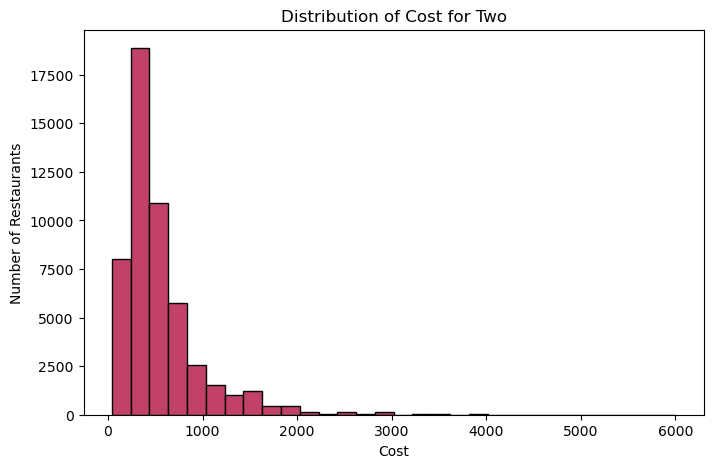

In [207]:
flare_color = sns.color_palette("flare", n_colors=1)[0]
plt.figure(figsize=(8, 5))
df['cost_for_two'].hist(bins=30, color=flare_color, edgecolor='black')
plt.title('Distribution of Cost for Two')
plt.xlabel('Cost')
plt.ylabel('Number of Restaurants')
plt.grid(False)
plt.show()

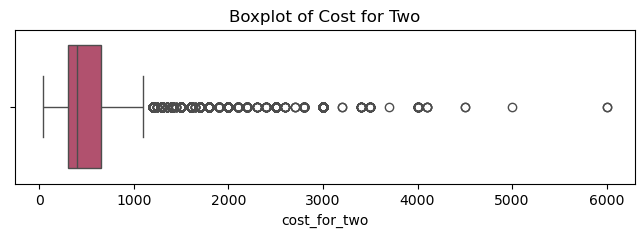

In [208]:
plt.figure(figsize=(8, 2))
sns.boxplot(x='cost_for_two', data=df, color=flare_color)
plt.title('Boxplot of Cost for Two')
plt.show()

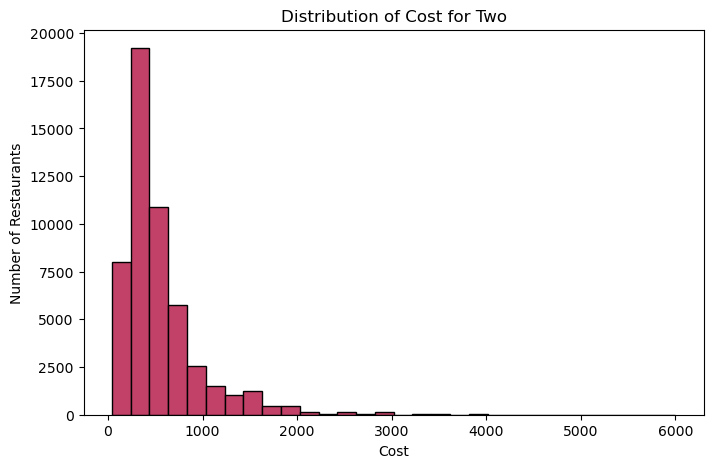

In [209]:
df[ 'cost_for_two'] = df['cost_for_two'].fillna(df['cost_for_two'].median())
plt.figure(figsize=(8, 5))
df['cost_for_two'].hist(bins=30, color=flare_color, edgecolor='black')
plt.title('Distribution of Cost for Two')
plt.xlabel('Cost')
plt.ylabel('Number of Restaurants')
plt.grid(False)
plt.show()

In [210]:
df['rest_type'] = df['rest_type'].fillna('Others')
df['cuisines'] = df['cuisines'].fillna('Unknown')
df['dish_liked'] = df['dish_liked'].fillna('Unknown')

In [211]:
df['online_order'] = df['online_order'].map({'Yes': True, 'No': False})
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,listed_type,listed_city
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,True,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,True,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,True,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,False,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,False,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [212]:

df['book_table'] = df['book_table'].map({'Yes': True, 'No': False})
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,listed_type,listed_city
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,True,True,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,True,False,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,True,False,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,False,False,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,False,False,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [213]:
df['rest_type'] = df['rest_type'].astype(str).apply(lambda x: ', '.join([s.strip().title() for s in x.split(',')]))
df['cuisines'] = df['cuisines'].astype(str).apply(lambda x: ', '.join([s.strip().title() for s in x.split(',')]))
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,listed_type,listed_city
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,True,True,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,True,False,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,True,False,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,False,False,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,False,False,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [214]:
df['listed_city'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

In [215]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', nan, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan 

In [216]:
df['location'].isna().sum()

np.int64(21)

In [217]:
listed_city_unique = df['listed_city'].unique()
location_unique = df['location'].unique()  
matches = pd.Series(listed_city_unique).isin(location_unique)
print(f"{matches.sum()} matches out of {len(matches)} total listed_city values are present in location.")

30 matches out of 30 total listed_city values are present in location.


In [218]:
df.groupby(by=['listed_city'], dropna=False)[['location']].value_counts()

listed_city  location             
BTM          BTM                      1130
             Koramangala 5th Block     439
             JP Nagar                  288
             HSR                       284
             Bannerghatta Road         254
                                      ... 
Whitefield   KR Puram                   17
             Marathahalli               12
             East Bangalore             10
             Bellandur                   4
             Old Airport Road            1
Name: count, Length: 707, dtype: int64

In [219]:
df['location'] = df['location'].fillna(df['listed_city'])

In [220]:
df1 = df.drop(columns=['listed_city']).copy()

In [221]:
locations = df1['location'].dropna().unique()
location_coords = {}
for loc in locations:
    try:
        full_loc = f"{loc}, Bangalore, India"
        location = geolocator.geocode(full_loc)
        if location:
            location_coords[loc] = (location.latitude, location.longitude)
        else:
            location_coords[loc] = (None, None)
        time.sleep(1)  # to respect usage limits
    except:
        location_coords[loc] = (None, None)


coords_df = pd.DataFrame.from_dict(location_coords, orient='index', columns=['lat', 'lon']).reset_index()
coords_df.columns = ['location', 'lat', 'lon']

In [222]:
location_df = df1['location'].value_counts().reset_index()
location_df.columns = ['location', 'restaurant_count']

map_df = location_df.merge(coords_df, on='location', how='left')
location_df.head()

,location,restaurant_count
0,BTM,5125
1,HSR,2524
2,Koramangala 5th Block,2507
3,JP Nagar,2235
4,Whitefield,2144


In [223]:
location_ratings = df1.groupby('location')['rate'].agg(['mean', 'count']).reset_index()
location_ratings.columns = ['location', 'average_rate', 'count']
location_ratings = location_ratings.dropna(subset=['average_rate'])
location_ratings = location_ratings.sort_values(by='average_rate', ascending=False)

In [224]:
top10_locations = location_ratings.head(10)
top10_locations.style.background_gradient(cmap='flare', axis=0)

,location,average_rate,count
51,Lavelle Road,4.142505,487
43,Koramangala 3rd Block,4.020419,191
81,St. Marks Road,4.017201,343
45,Koramangala 5th Block,4.005821,2319
12,Church Street,3.992125,546
75,Sankey Road,3.965385,26
44,Koramangala 4th Block,3.918668,841
15,Cunningham Road,3.901053,475
70,Residency Road,3.863636,605
52,MG Road,3.855857,811


In [225]:
df['rest_type'].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', 'Others', 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',
 

In [226]:
df['listed_type'].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [227]:
pd.Series(df['listed_type'].unique()).isin(df['rest_type'].unique()).shape


(7,)

In [228]:
df.groupby(by=['listed_type'], dropna=False)[['rest_type']].value_counts()

listed_type    rest_type              
Buffet         Casual Dining              599
               Casual Dining, Bar          88
               Fine Dining                 78
               Lounge                      21
               Casual Dining, Cafe         15
                                         ... 
Pubs and bars  Cafe                         1
               Casual Dining                1
               Delivery                     1
               Dessert Parlor, Cafe         1
               Sweet Shop, Quick Bites      1
Name: count, Length: 315, dtype: int64

In [229]:
df1['rest_type'] = df1['rest_type'].fillna(df1['listed_type'])

In [230]:
df1['delivery'] = df1['listed_type'].str.contains('delivery', case=False, na=False)
df1['delivery'].value_counts()

delivery
True     25942
False    25775
Name: count, dtype: int64

In [231]:
df1['rest_type'] = df1['rest_type'].str.lower().str.strip().replace({r'\bcafes\b': 'cafe', r'\bdesserts\b': 'dessert parlor'}, regex=True)

In [232]:
x = df1['rest_type'].dropna().str.split(',\s*').explode().str.strip()
dummies = pd.get_dummies(x).groupby(x.index).max() .add_prefix('type_')
df1 = pd.concat([df1, dummies], axis=1)
df1.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,...,type_lounge,type_meat shop,type_mess,type_microbrewery,type_others,type_pop up,type_pub,type_quick bites,type_sweet shop,type_takeaway
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,True,True,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,casual dining,...,False,False,False,False,False,False,False,False,False,False
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,True,False,4.1,787,080 41714161,Banashankari,casual dining,...,False,False,False,False,False,False,False,False,False,False
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,True,False,3.8,918,+91 9663487993,Banashankari,"cafe, casual dining",...,False,False,False,False,False,False,False,False,False,False
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,False,False,3.7,88,+91 9620009302,Banashankari,quick bites,...,False,False,False,False,False,False,False,True,False,False
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,False,False,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,casual dining,...,False,False,False,False,False,False,False,False,False,False


In [233]:
df1.loc[df1['type_delivery'] == True, 'delivery'] = True

In [234]:
df2 = df1.copy()

In [235]:
y = df2['cuisines'].dropna().str.split(',\s*').explode().str.strip()
counts = y.value_counts()  
dummies2 = (
    pd.get_dummies(y)
      .loc[:, counts[counts > 1000].index.tolist()]
      .groupby(y.index)
      .max()
      .add_prefix('cuisine_')
)

df2 = pd.concat([df2, dummies2], axis=1)
df2.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'cost_for_two', 'reviews_list', 'menu_item', 'listed_type', 'delivery',
       'type_bakery', 'type_bar', 'type_beverage shop', 'type_bhojanalya',
       'type_cafe', 'type_casual dining', 'type_club', 'type_confectionery',
       'type_delivery', 'type_dessert parlor', 'type_dhaba',
       'type_fine dining', 'type_food court', 'type_food truck',
       'type_irani cafee', 'type_kiosk', 'type_lounge', 'type_meat shop',
       'type_mess', 'type_microbrewery', 'type_others', 'type_pop up',
       'type_pub', 'type_quick bites', 'type_sweet shop', 'type_takeaway',
       'cuisine_North Indian', 'cuisine_Chinese', 'cuisine_South Indian',
       'cuisine_Fast Food', 'cuisine_Biryani', 'cuisine_Continental',
       'cuisine_Desserts', 'cuisine_Cafe', 'cuisine_Beverages',
       'cuisine_Italian', 'cuisine_Bakery', 'cuisine_Street Food',
 

In [236]:
def Zscore_outlier(col):
    out=[]
    m = np.mean(col)
    sd = np.std(col)
    for i in col: 
        z = (i-m)/sd
        if np.abs(z) > 3: 
            out.append(i)
    out.sort()
    print("Outliers:",out)

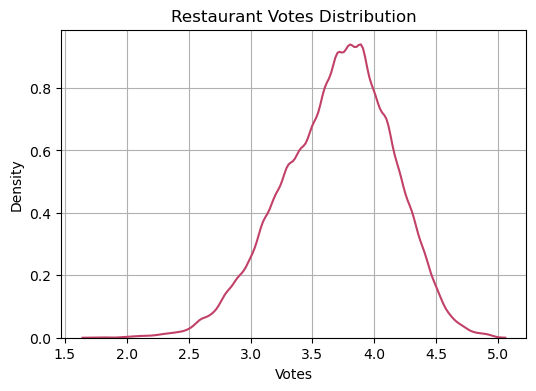

In [237]:
flare_color = sns.color_palette("flare", 5)[2] 
plt.figure(figsize=(6, 4))
sns.kdeplot(df['rate'].dropna(), color=flare_color)
plt.title('Restaurant Votes Distribution')
plt.xlabel('Votes')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [238]:
Zscore_outlier(df['rate'].dropna())

Outliers: [1.8, 1.8, 1.8, 1.8, 1.8, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.1, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3, 2.3]


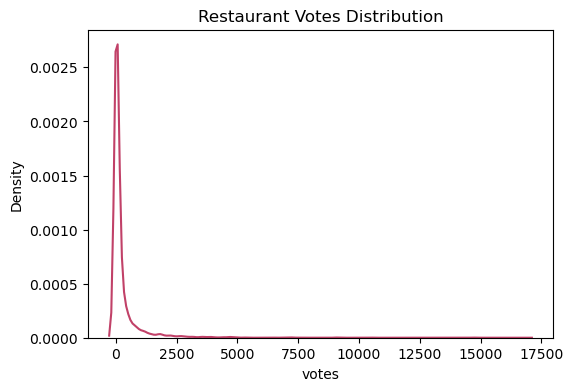

In [239]:
plt.figure(figsize=(6, 4))
sns.kdeplot(df['votes'].dropna(), color=flare_color)
plt.title('Restaurant Votes Distribution')
plt.xlabel('votes')
plt.ylabel('Density')
plt.show()

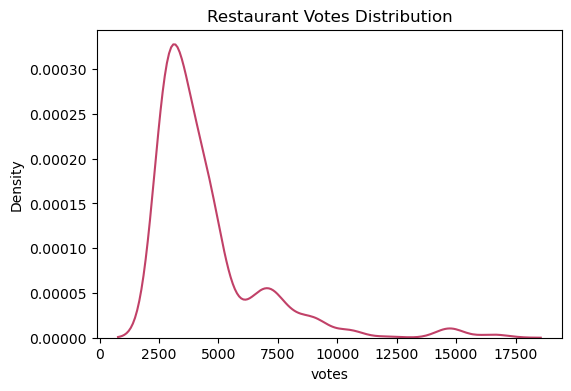

In [240]:
plt.figure(figsize=(6, 4))
sns.kdeplot(df['votes'][df['votes'] > 2500].dropna(), color=flare_color)
plt.title('Restaurant Votes Distribution')
plt.xlabel('votes')
plt.ylabel('Density')
plt.show()

In [241]:
Zscore_outlier(df['votes'][df['votes'] > 2500].dropna())

Outliers: [12121, 12121, 14654, 14654, 14654, 14690, 14694, 14704, 14710, 14710, 14710, 14717, 14717, 14723, 14723, 14723, 14726, 14956, 14956, 16345, 16345, 16345, 16832, 16832, 16832]


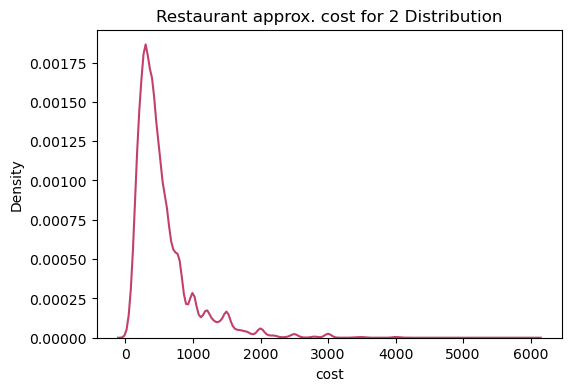

In [242]:
plt.figure(figsize=(6, 4))
sns.kdeplot(df['cost_for_two'].dropna(), color=flare_color)
plt.title('Restaurant approx. cost for 2 Distribution')
plt.xlabel('cost')
plt.ylabel('Density')
plt.show()

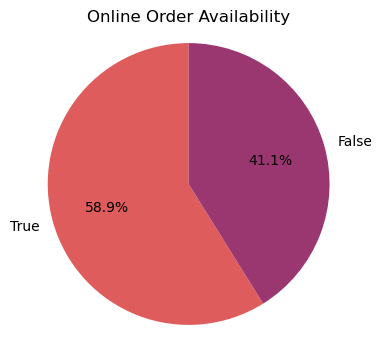

In [243]:
flare_colors = sns.color_palette("flare", n_colors=2).as_hex()
online_order_counts = df['online_order'].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(online_order_counts, labels=online_order_counts.index, colors=flare_colors, 
        autopct='%1.1f%%', startangle=90)
plt.title('Online Order Availability')
plt.axis('equal')
plt.show()

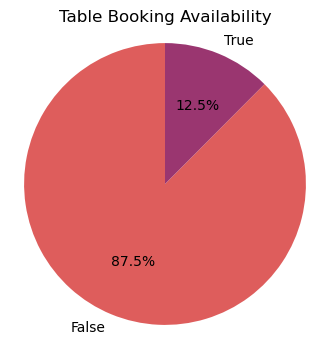

In [244]:
book_table_counts = df['book_table'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(book_table_counts, 
        labels=book_table_counts.index, 
        colors=flare_colors, 
        autopct='%1.1f%%', 
        startangle=90)
plt.title('Table Booking Availability')
plt.axis('equal')
plt.show()

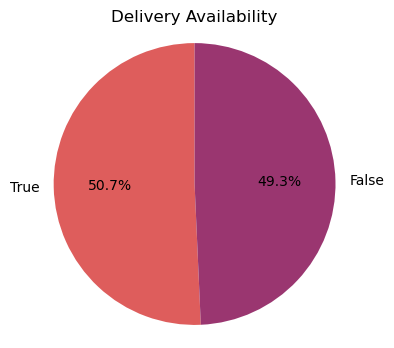

In [245]:
delivery_counts = df1['delivery'].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(
    delivery_counts, 
    labels=delivery_counts.index, 
    colors=flare_colors, 
    autopct='%1.1f%%', 
    startangle=90)
plt.title('Delivery Availability')
plt.axis('equal')
plt.show()


In [246]:
df.describe()

,rate,votes,cost_for_two
count,41665.000000,51717.000000,51717.000000
mean,3.700449,283.697527,554.391689
std,0.440513,803.838853,437.563723
min,1.800000,0.000000,40.000000
25%,3.400000,7.000000,300.000000
50%,3.700000,41.000000,400.000000
75%,4.000000,198.000000,650.000000
max,4.900000,16832.000000,6000.000000
